CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                     │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 577.6080 - mae: 22.0871 - val_loss: 489.1367 - val_mae: 20.5194
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 488.5459 - mae: 20.0702 - val_loss: 373.1489 - val_mae: 17.6212
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 318.9935 - mae: 15.5554 - val_loss: 174.5983 - val_mae: 11.2753
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 127.3700 - mae: 9.1045 - val_loss: 55.9002 - val_mae: 5.4708
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 63.7349 - mae: 6.2404 - val_loss: 32.5687 - val_mae: 3.9319
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 34.5487 - mae: 4.4575 - val_loss: 26.5960 - val_mae: 3.5967
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 25.0770 - mae: 3.7748 - val_loss: 25.8206 - val_mae: 3.6469
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 21.7486 - mae: 3.4905 - val_loss: 25.2628 - val_mae: 3.5528
Epoch 9/100
21/21 ━━━━━━━━━

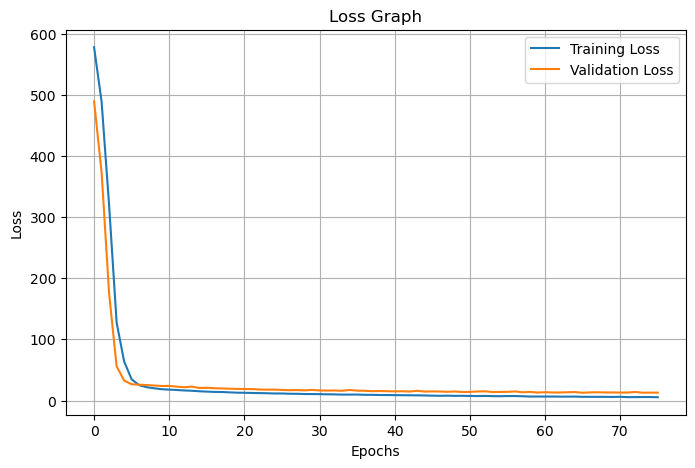

In [13]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Load Dataset
data = pd.read_csv("HousingData.csv")

# Check missing values
print(data.isnull().sum())

# Fill missing values
data = data.fillna(data.mean())

# Features and Target
X = data.drop('MEDV', axis=1)
y = data['MEDV']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build DNN Model
model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    
    Dense(1, activation='linear')
    
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss (MSE):", round(loss, 2))
print("Test MAE:", round(mae, 2))

# Predictions
predictions = model.predict(X_test)

print("\nActual vs Predicted:\n")

for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {predictions[i][0]:.2f}")

# Plot Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()